In [111]:
from langgraph.graph import START, END, StateGraph, add_messages
from langgraph.types import Send
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_community.document_loaders import WikipediaLoader
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, AnyMessage, get_buffer_string
from langchain_core.runnables import RunnableConfig

from pydantic import BaseModel, Field

from IPython.display import Image, display, Markdown
from dotenv import load_dotenv

import os
from typing import Literal, List, Annotated
import operator

In [56]:
load_dotenv()
def _check_env(var: str):
    if not os.environ.get(var):
        raise ValueError(f"No env variable for {var}")

In [57]:
_check_env("OPENAI_API_KEY")
_check_env("LANGSMITH_API_KEY")
_check_env("TAVILY_API_KEY")

In [58]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)

### Schemas

In [59]:
class AnalystPersona(BaseModel): #pydantic for validation
    name: str = Field(
        description="Name of the analyst."
    )
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )

    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

class AnalystPersonas(BaseModel):
    analysts: List[AnalystPersona] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )

class WholeGraphState(BaseModel):
    max_analysts: int
    topic: str
    human_analyst_feedback: str | None = None
    analysts: list[AnalystPersona] | None = None
    # document_type: Literal['article', 'research_paper']

### Analysts

In [60]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [61]:
def create_analysts(state: WholeGraphState) -> dict:
    topic = state.topic
    max_analysts = state.max_analysts
    human_analyst_feedback = state.human_analyst_feedback or ''
    
    structured_llm = llm.with_structured_output(AnalystPersonas)
    system_message = analyst_instructions.format(topic=topic, human_analyst_feedback=human_analyst_feedback, max_analysts=max_analysts)
    
    personas = structured_llm.invoke([SystemMessage(system_message)] + [HumanMessage(content="Generate the analyst personas")])
    
    return {"analysts" : personas.analysts}

def get_human_feedback(state: WholeGraphState):
    pass

def should_continue(state: WholeGraphState) -> str:
    '''Return next node after human feedback'''
    human_analyst_feedback = state.human_analyst_feedback or None
    if human_analyst_feedback:
        return 'create_analysts'
    return END

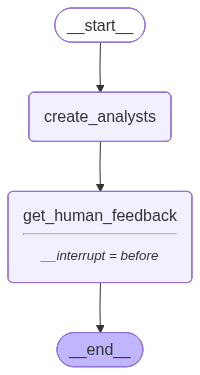

In [62]:
builder = StateGraph(WholeGraphState)

builder.add_node("create_analysts", create_analysts)
builder.add_node("get_human_feedback", get_human_feedback)

builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "get_human_feedback")
builder.add_conditional_edges("get_human_feedback", should_continue)

memory = MemorySaver()
graph = builder.compile(interrupt_before=['get_human_feedback'], checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


### Create Analysts Demonstration

In [63]:
graph_state = WholeGraphState(
    max_analysts=3,
    topic="The adoption of AI in SMEs in Africa",
    human_analyst_feedback=None,
    analysts=None  
)
thread = RunnableConfig(configurable= {"thread_id": "1"})

for event in graph.stream(graph_state, config=thread, stream_mode="values"):
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 


Name: Dr. Amina Okafor
Affiliation: University of Lagos
Role: Technology Adoption Specialist
Description: Dr. Amina Okafor focuses on understanding the factors that influence the adoption of AI technologies in small and medium-sized enterprises (SMEs) across Africa. Her research is driven by a desire to identify the barriers and enablers of AI adoption, such as infrastructure, cost, and skill levels. She is particularly interested in how these factors vary across different regions and industries within Africa.
--------------------------------------------------
Name: Kwame Mensah
Affiliation: African Development Bank
Role: Economic Impact Analyst
Description: Kwame Mensah analyzes the economic implications of AI adoption in African SMEs. His work involves assessing how AI can drive growth, improve efficiency, and create new business opportunities. He is concerned with the potential for AI to transform traditional business models and the broader economic impact on employment and producti

In [64]:
current_state = graph.get_state(thread)
print(current_state.next)
current_state

('get_human_feedback',)


StateSnapshot(values={'max_analysts': 3, 'topic': 'The adoption of AI in SMEs in Africa', 'human_analyst_feedback': None, 'analysts': [AnalystPersona(name='Dr. Amina Okafor', affiliation='University of Lagos', role='Technology Adoption Specialist', description='Dr. Amina Okafor focuses on understanding the factors that influence the adoption of AI technologies in small and medium-sized enterprises (SMEs) across Africa. Her research is driven by a desire to identify the barriers and enablers of AI adoption, such as infrastructure, cost, and skill levels. She is particularly interested in how these factors vary across different regions and industries within Africa.'), AnalystPersona(name='Kwame Mensah', affiliation='African Development Bank', role='Economic Impact Analyst', description='Kwame Mensah analyzes the economic implications of AI adoption in African SMEs. His work involves assessing how AI can drive growth, improve efficiency, and create new business opportunities. He is concer

In [65]:
graph.update_state(thread, 
                   {"human_analyst_feedback":"Add in someone from a startup to add an entrepreneur perspective"},
                   as_node="get_human_feedback")

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0b7ff8-929e-6f5f-8002-a45660bb55ce'}}

In [66]:
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Name: Dr. Amina Okafor
Affiliation: University of Lagos
Role: Technology Adoption Specialist
Description: Dr. Amina Okafor focuses on understanding the factors that influence the adoption of AI technologies in small and medium-sized enterprises (SMEs) across Africa. Her research is driven by a desire to identify the barriers and enablers of AI adoption, such as infrastructure, cost, and skill levels. She is particularly interested in how these factors vary across different regions and industries within Africa.
--------------------------------------------------
Name: Kwame Mensah
Affiliation: African Development Bank
Role: Economic Impact Analyst
Description: Kwame Mensah analyzes the economic implications of AI adoption in African SMEs. His work involves assessing how AI can drive growth, improve efficiency, and create new business opportunities. He is concerned with the potential for AI to transform traditional business models and the broader economic impact on employment and producti

### Conduct Interview

#### Ask Question

In [112]:
class InterviewState(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages]
    context: Annotated[list[str], operator.add]
    interview: str | None = None
    max_num_of_turns: int
    analyst: AnalystPersona
    sections: list[str]
    

question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""


In [113]:
def generate_question(state: InterviewState) -> dict:
    analyst = state.analyst
    messages = state.messages

    system_message = question_instructions.format(goals=analyst.persona)
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
    
    return {"messages" : [question]}

def route_messages(state: InterviewState, 
                   name: str = "expert"):
    ''' Route between question and answer '''
    
    messages = state.messages
    max_num_turns = state.max_num_of_turns

    # Check the number of expert answers 
    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    # End if expert has answered more than the max turns
    if num_responses >= max_num_turns:
        return 'save_interview'

    # This router is run after each question
    # If the question content contains thank you so much for your help, it skips to save the interview
    last_question = messages[-1] 
    if "Thank you so much for your help" in last_question.content:
        return 'save_interview'
    
    return [
            Send("search_web", state),
            Send("search_wikipedia", state)
        ]

#### Search Web + Wikipedia

- Using Tavily to search for relevant information to answer the question

In [114]:
class SearchQuery(BaseModel):
    search_query: str | None = Field(None, description="Search query for retrieval.")

search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

In [115]:
tavily_search = TavilySearch(max_results=3)

def search_web(state: InterviewState) -> dict:
    '''Search web using Tavily'''
    structured_llm = llm.with_structured_output(SearchQuery)
    output = structured_llm.invoke([search_instructions] +  state.messages)

    output = tavily_search.invoke({"query": output.search_query})
    search_results = output.get("results", output)
    
    formatted_search_results = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_results
        ]
    )

    return {"context": [formatted_search_results]}

def search_wikipedia(state: InterviewState) -> dict:
    '''Search Wikipidea'''
    structured_llm = llm.with_structured_output(SearchQuery)
    output = structured_llm.invoke([search_instructions]+state.messages)
    
    search_results = WikipediaLoader(query=output.search_query, load_max_docs=3).load()
    
    formatted_search_results = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_results
        ]
    )

    return {"context": [formatted_search_results]}

#### Generate Answer

In [116]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""

In [117]:
def generate_answer(state: InterviewState):
    """ Answer a question """
    # Get state
    analyst = state.analyst
    messages = state.messages
    context = state.context

    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    # Name the message as coming from the expert
    answer.name = "expert"
    
    return {"messages": [answer]}

def save_interview(state: InterviewState):
    ''' Save interviews '''
    
    interview = get_buffer_string(state.messages)
    
    return {"interview": interview}

#### Write Section

In [118]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [119]:
def write_section(state: InterviewState):

    """ Node to answer a question """

    interview = state.interview
    context = state.context
    analyst = state.analyst
   
    # Write section using either the both source docs and interview
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context} {interview}")]) 
                
    return {"sections": [section.content]}

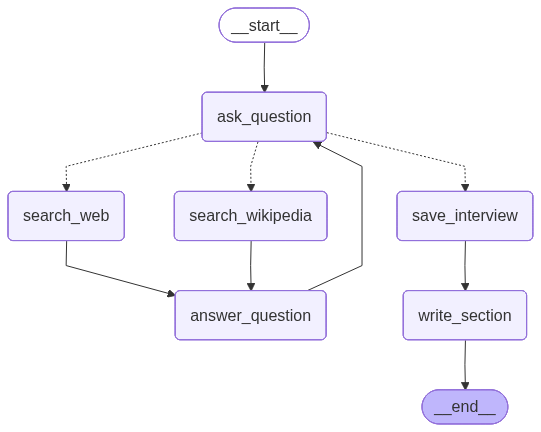

In [120]:
interview_builder = StateGraph(InterviewState)
interview_builder.add_node("ask_question", generate_question)
interview_builder.add_node("search_web", search_web)
interview_builder.add_node("search_wikipedia", search_wikipedia)
interview_builder.add_node("answer_question", generate_answer)
interview_builder.add_node("save_interview", save_interview)
interview_builder.add_node("write_section", write_section)

# Flow
interview_builder.add_edge(START, "ask_question")
interview_builder.add_conditional_edges("ask_question", route_messages, path_map=["search_web", "search_wikipedia", "save_interview"])
interview_builder.add_edge("search_web", "answer_question")
interview_builder.add_edge("answer_question", "ask_question")
interview_builder.add_edge("search_wikipedia", "answer_question")
interview_builder.add_edge("save_interview", "write_section")
interview_builder.add_edge("write_section", END)

memory = MemorySaver()
interview_graph = interview_builder.compile(checkpointer=memory).with_config(run_name="Conduct Interviews")

display(Image(interview_graph.get_graph().draw_mermaid_png()))


#### Trial Interview

In [121]:
trial_interview = InterviewState(
    messages=[],
    context=[],
    max_num_of_turns=2,
    analyst=analysts[0],
    sections=[]
)
thread = RunnableConfig(
    configurable={
        "thread_id":1
    }
)
interview = interview_graph.invoke(trial_interview,thread)
Markdown(interview['sections'][0])

## Unlocking AI Potential: Overcoming Barriers and Driving Growth in African SMEs

### Summary

In the rapidly evolving landscape of technology, the adoption of Artificial Intelligence (AI) by Small and Medium-sized Enterprises (SMEs) in Africa presents both significant opportunities and challenges. Dr. Amina Okafor, a leading researcher in technology adoption, highlights the critical barriers and enablers of AI integration in African SMEs, emphasizing the socio-economic impacts and potential for growth and innovation.

African SMEs that fail to adopt AI technologies by 2027 are likely to face substantial competitive disadvantages. Businesses that have embraced AI report a 15.1% higher chance of significant revenue growth and a 32% improvement in productivity. AI-powered tools, such as chatbots, enable SMEs with limited human resources to deliver world-class customer service, while digital platforms help overcome traditional geographic limitations [1].

Despite the potential benefits, several barriers hinder AI adoption in African SMEs. Infrastructure limitations, such as inadequate internet connectivity and limited access to advanced computing resources, pose significant challenges. Additionally, there is a notable skills gap, with a shortage of professionals proficient in AI technologies. Regulatory uncertainties further complicate the landscape, creating hesitancy among SMEs to invest in AI due to compliance concerns [1].

Cost remains a critical barrier, even though AI implementation costs have decreased, with solutions starting at approximately R10,000 ($550). For many SMEs operating on tight budgets, this initial investment can be prohibitive. Moreover, a lack of senior management support, particularly in South African state-owned enterprises, can impede AI adoption efforts [2].

To overcome these challenges, strategic approaches are essential. SMEs are encouraged to conduct readiness assessments and prioritize high-impact, low-barrier applications. Forming partnerships with technology providers and academic institutions can provide access to expertise and resources, facilitating knowledge transfer and technical support [1]. Incremental adoption, starting with cost-effective AI tools, allows SMEs to gradually expand their use of AI as they build capacity and confidence [3].

Government support plays a crucial role in enabling AI adoption. In countries like South Africa, Kenya, and Nigeria, supportive policies and better digital infrastructure have contributed to higher adoption rates. Government initiatives that offer financial incentives, training programs, and infrastructure development can significantly aid SMEs in integrating AI technologies [1].

Enhancing digital literacy among employees is another critical enabler. Training staff to effectively use digital tools and understand the socio-political impacts of these technologies can lead to more informed decision-making and innovation [4].

In conclusion, while the path to AI adoption in African SMEs is fraught with challenges, strategic approaches and supportive frameworks can unlock significant growth and innovation potential. By leveraging AI technologies, SMEs can enhance their competitiveness and contribute to socio-economic development across the continent.

### Sources
[1] https://www.linkedin.com/pulse/what-consequences-ai-non-adoption-african-smes-2027-solutions-cmlxf  
[2] https://bussecon.com/ojs/index.php/ijbes/article/view/867  
[3] https://journalijsra.com/sites/default/files/fulltext_pdf/IJSRA-2025-0009.pdf  
[4] https://en.wikipedia.org/wiki/Digital_literacy  